# Практическое задание № 2. Нейронные сети


**Работу выполнила:**

Охрименко Ева Дмитриевна 409290

## Прогнозирование цены на жилье с помощью нейросетевой регрессионной модели

Необходимо по имеющимся данным о ценах на жильё предсказать окончательную цену каждого дома с учетом характеристик домов с использованием нейронной сети. Описание набора данных  содержит 80 классов (набор переменых) классификации оценки типа жилья, и находится в файле `data_description.txt`.

В работе требуется дополнить раздел «Моделирование» в подразделе «Построение и обучение модели» создать и инициализировать последовательную модель нейронной сети с помощью фрэймворков тренировки нейронных сетей как: Torch или Tensorflow. Скомпилировать нейронную сеть выбрав функцию потерь и оптимизатор соответственно. Оценить точность полученных результатов. Вывести предсказанные данные о продаже.


### Импорт библиотек
Импортируем необходимые библиотеки:

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import drive
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from sklearn.metrics import mean_absolute_error, mean_squared_error
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Считываем набор данных


Загрузим набор данных и присвоим следующими переменные:

* `train_data`: данные, используемые для обучения модели
* `test_data`: данные, используемые для проверки модели

In [2]:
train_data = pd.read_csv('/content/drive/MyDrive/notebook_files/train.csv')
test_data = pd.read_csv('/content/drive/MyDrive/notebook_files/test.csv')

## Подготовка данных
### Отобразим обучающие и проверочные данные:

In [3]:
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
test_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


Как можно видеть, `train_data` имеет на один столбец больше, чем `test_data`, это столбец `SalePrice`, для обучения модели перед применением ее для предсказания меток в test_data.

### Проверяем нет ли тестовые данные пустых значений значений (Nan)

Построим функцию `def missing_value_checker` для проверки и подсчёта пропущеных значений в test_data. А также выведем тип данных этих значений.


In [5]:
def missing_value_checker(data):
    list = []
    for feature, content in data.items():
        if data[feature].isnull().values.any():

            sum = data[feature].isna().sum()

            type = data[feature].dtype

            print (f'{feature}: {sum}, type: {type}')

            list.append(feature)
    print(list)

    print(len(list))

missing_value_checker(test_data)

MSZoning: 4, type: object
LotFrontage: 227, type: float64
Alley: 1352, type: object
Utilities: 2, type: object
Exterior1st: 1, type: object
Exterior2nd: 1, type: object
MasVnrType: 894, type: object
MasVnrArea: 15, type: float64
BsmtQual: 44, type: object
BsmtCond: 45, type: object
BsmtExposure: 44, type: object
BsmtFinType1: 42, type: object
BsmtFinSF1: 1, type: float64
BsmtFinType2: 42, type: object
BsmtFinSF2: 1, type: float64
BsmtUnfSF: 1, type: float64
TotalBsmtSF: 1, type: float64
BsmtFullBath: 2, type: float64
BsmtHalfBath: 2, type: float64
KitchenQual: 1, type: object
Functional: 2, type: object
FireplaceQu: 730, type: object
GarageType: 76, type: object
GarageYrBlt: 78, type: float64
GarageFinish: 78, type: object
GarageCars: 1, type: float64
GarageArea: 1, type: float64
GarageQual: 78, type: object
GarageCond: 78, type: object
PoolQC: 1456, type: object
Fence: 1169, type: object
MiscFeature: 1408, type: object
SaleType: 1, type: object
['MSZoning', 'LotFrontage', 'Alley', 'Ut

Проверяем какие признаки в таблице можно оставить, а какие удалить. Если пропущенных значений слишком много, то удалим признак. Если их небольшое количество, то заполним `mean` или `median` для чисел, новая категория `missing` для строковых объектов.

В соответствии с этим:

– удалим ['Alley', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'];

– заполним числовое отсутствующее значение значением `mean`;

– заполним строковое отсутствующее значение значением `missing`.

In [6]:
test_edited = test_data.drop(['Alley','FireplaceQu','PoolQC', 'Fence', 'MiscFeature'], axis=1)
train_edited = train_data.drop(['Alley','FireplaceQu','PoolQC', 'Fence', 'MiscFeature'], axis=1)

def nan_filler(data):
    for label, content in data.items():
        if pd.api.types.is_numeric_dtype(content):
            data[label] = content.fillna(content.median())
        else:
            data[label] = content.astype("category").cat.as_ordered()
            data[label] = pd.Categorical(content).codes+1

nan_filler(test_edited)
nan_filler(train_edited)

### Перепроверим наши данные:

In [7]:
missing_value_checker(test_edited)

[]
0


In [8]:
missing_value_checker(train_edited)

[]
0


In [9]:
train_edited.shape, test_edited.shape

((1460, 76), (1459, 75))

In [10]:
test_edited.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1459 non-null   int8   
 3   LotFrontage    1459 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   int8   
 6   LotShape       1459 non-null   int8   
 7   LandContour    1459 non-null   int8   
 8   Utilities      1459 non-null   int8   
 9   LotConfig      1459 non-null   int8   
 10  LandSlope      1459 non-null   int8   
 11  Neighborhood   1459 non-null   int8   
 12  Condition1     1459 non-null   int8   
 13  Condition2     1459 non-null   int8   
 14  BldgType       1459 non-null   int8   
 15  HouseStyle     1459 non-null   int8   
 16  OverallQual    1459 non-null   int64  
 17  OverallCond    1459 non-null   int64  
 18  YearBuil

In [11]:
train_edited.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   int8   
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   int8   
 6   LotShape       1460 non-null   int8   
 7   LandContour    1460 non-null   int8   
 8   Utilities      1460 non-null   int8   
 9   LotConfig      1460 non-null   int8   
 10  LandSlope      1460 non-null   int8   
 11  Neighborhood   1460 non-null   int8   
 12  Condition1     1460 non-null   int8   
 13  Condition2     1460 non-null   int8   
 14  BldgType       1460 non-null   int8   
 15  HouseStyle     1460 non-null   int8   
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

### Разделим данные

Поскольку мы не знаем метку (Цена) тестовых данных, для оценки модели, чтобы получить лучшую модель перед прогнозированием тестовых данных, разделим данные в файле train.scv на обучающие и проверочные данные, соотношение составляет 20%.

In [12]:
X = train_edited.drop('SalePrice', axis=1)
y = train_edited['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2)

In [13]:
X_train.shape, test_edited.shape

((1168, 75), (1459, 75))

## Моделирование

### Построение и обучение модели


Создайте последовательную модель нейронной сети с помощью фрэймворков тренировки нейронных сетей как: Torch или Tensorflow.

In [18]:
tf.random.set_seed(40) #Для обеспечения воспроизводимости результатов устанавливается функция seed
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1)  # Выход для регрессии
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Скомпилируйте нейронную сеть, выбрав функцию потерь и оптимизатор соответственно.

In [19]:
model.compile(
    optimizer='adam',   # Оптимизатор Adam
    loss='mse',  # Функция потерь - среднеквадратичная ошибка
    metrics=['mae']    # Метрика - средняя абсолютная ошибка
)

Обучите модель на обучающих данных `X_train` и `y_train` задав гиперпараметры вашей модели нейронной сети, например количество эпох (epochs), размер мини-выборки (batch_size) и другие.

In [20]:
history = model.fit(
    X_train, y_train,  # Обучающие данные
    validation_data=(X_val, y_val), # Валидационные данные
    epochs=50, # Количество эпох
    batch_size=32,   # Размер мини-выборки
)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 40661389312.0000 - mae: 184631.1875 - val_loss: 30304524288.0000 - val_mae: 159663.4844
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 34680324096.0000 - mae: 168993.4062 - val_loss: 23612696576.0000 - val_mae: 138045.5000
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 26302760960.0000 - mae: 143501.6875 - val_loss: 15519406080.0000 - val_mae: 106681.3047
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 17115117568.0000 - mae: 109563.4453 - val_loss: 9331986432.0000 - val_mae: 72131.2500
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10993162240.0000 - mae: 76103.0000 - val_loss: 6925232640.0000 - val_mae: 51142.9609
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8990444544.0000 - mae: 56088.3086 - val_loss: 6402915840.0000 - val_mae: 46055.9766
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8508671488.0000 - mae: 50094.1055 - val_loss: 6070961152.0000 - val_mae: 45

**Оцените полученные результаты**

{'loss': [38621949952.0, 32434538496.0, 23806760960.0, 14864507904.0, 9061199872.0, 6902675968.0, 6265568768.0, 5895995392.0, 5564957184.0, 5259244544.0, 4979828224.0, 4726452736.0, 4497623552.0, 4290578176.0, 4102304000.0, 3932690944.0, 3777155584.0, 3634172416.0, 3503770624.0, 3385146880.0, 3275738368.0, 3172694528.0, 3074580992.0, 2982044672.0, 2894673920.0, 2810354176.0, 2729766912.0, 2654200576.0, 2584144128.0, 2519884032.0, 2461496832.0, 2408536064.0, 2361306368.0, 2319124480.0, 2281600256.0, 2248665344.0, 2219991296.0, 2194766848.0, 2172553984.0, 2153350144.0, 2136569216.0, 2121851008.0, 2108824832.0, 2097414400.0, 2087557248.0, 2078784000.0, 2070930176.0, 2063859072.0, 2057555712.0, 2051827584.0], 'mae': [179077.8125, 162089.40625, 134495.703125, 98927.359375, 67357.5234375, 51543.859375, 47406.73828125, 46269.5859375, 45614.99609375, 45072.41015625, 44579.90625, 44092.5703125, 43606.4296875, 43101.86328125, 42610.66796875, 42089.98828125, 41534.37109375, 40928.015625, 40306.74

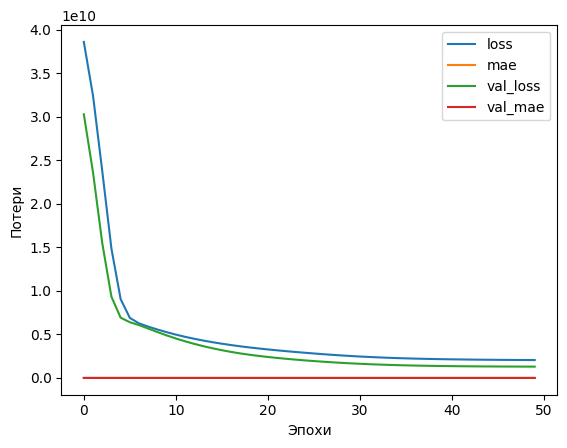

In [21]:
pd.DataFrame(history.history).plot()
plt.ylabel('Потери')
plt.xlabel('Эпохи')
print(history.history)

In [22]:
scores = model.evaluate(X_val, y_val, verbose=0)  # Оценка модели на валидационных данных
print(f"Потеря (val.): {scores[0]:.2f}")
print(f"MAE (val.): {scores[1]:.2f}")

Потеря (val.): 1297196544.00
MAE (val.): 24864.69


### Прогнозирование

In [23]:
preds = model.predict(test_edited)  # Прогнозирование на тестовых данных
preds

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[143902.5  ],
       [179029.55 ],
       [194538.03 ],
       ...,
       [195779.67 ],
       [ 99117.805],
       [222116.88 ]], dtype=float32)

In [24]:
#пример
output = pd.DataFrame(
{
    'Id':test_data['Id'],
    'SalePrice': np.squeeze(preds)
})
output


,Id,SalePrice
0,1461,143902.500000
1,1462,179029.546875
2,1463,194538.031250
3,1464,195184.562500
4,1465,164102.312500
...,...,...
1454,2915,77210.304688
1455,2916,95226.039062
1456,2917,195779.671875
1457,2918,99117.804688


## Задание


В задние представлено логика выполнения с использование tensorflow/keras. Выполнять можно как с использованием tensorflow/keras, так и pytorch.


**При выполнении:**

- [ ]  Выведите отчет нейросетевой регрессионной модели, для  прогнозирование цены на жилье.



In [25]:
print("Информация о модели:")
print("Входной слой: 256 нейронов")
print("Выходной слой: 1 нейрон")
print(f"\nРезультаты на валидационных данных:")
print(f"MSE: {scores[0]:.2f}")
print(f"MAE: {scores[1]:.2f}")

# Анализ предсказаний
y_pred = model.predict(X_val)
residuals = y_val - y_pred.flatten()
print(f"\nСтатистика остатков:")
print(f"Средний остаток: {np.mean(residuals):.2f}")
print(f"Стандартное отклонение остатков: {np.std(residuals):.2f}")

Информация о модели:
Входной слой: 256 нейронов
Выходной слой: 1 нейрон

Результаты на валидационных данных:
MSE: 1297196544.00
MAE: 24864.69
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Статистика остатков:
Средний остаток: -6064.05
Стандартное отклонение остатков: 35502.45


Дополнительные функции

In [26]:
def plots(name, df_results):

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # 1. MAE
    axes[0, 0].plot(df_results[name], df_results['mae'], 'b-')
    axes[0, 0].set_xscale('log')
    axes[0, 0].set_xlabel(name)
    axes[0, 0].set_ylabel('MAE')
    axes[0, 0].set_title('MAE')
    axes[0, 0].grid(True)

    # 2. MSE
    axes[0, 1].plot(df_results[name], df_results['mse'], 'g-')
    axes[0, 1].set_xscale('log')
    axes[0, 1].set_xlabel(name)
    axes[0, 1].set_ylabel('MSE')
    axes[0, 1].set_title('MSE')
    axes[0, 1].grid(True)

    # 3. Train Loss
    axes[0, 2].plot(df_results[name], df_results['loss_train'], 'r-')
    axes[0, 2].set_xscale('log')
    axes[0, 2].set_xlabel(name)
    axes[0, 2].set_ylabel('Train Loss')
    axes[0, 2].set_title('Train Loss')
    axes[0, 2].grid(True)

    # 4. Validation Loss
    axes[1, 0].plot(df_results[name], df_results['loss_val'], 'm-')
    axes[1, 0].set_xscale('log')
    axes[1, 0].set_xlabel(name)
    axes[1, 0].set_ylabel('Val Loss')
    axes[1, 0].set_title('Validation Loss')
    axes[1, 0].grid(True)

    # 5. Train MAE
    axes[1, 1].plot(df_results[name], df_results['mae_train'], 'c-')
    axes[1, 1].set_xscale('log')
    axes[1, 1].set_xlabel(name)
    axes[1, 1].set_ylabel('Train MAE')
    axes[1, 1].set_title('Train MAE')
    axes[1, 1].grid(True)

    # 6. Validation MAE
    axes[1, 2].plot(df_results[name], df_results['mae_val'], 'y-')
    axes[1, 2].set_xscale('log')
    axes[1, 2].set_xlabel(name)
    axes[1, 2].set_ylabel('Val MAE')
    axes[1, 2].set_title('Validation MAE')
    axes[1, 2].grid(True)

    plt.tight_layout()
    plt.show()


In [27]:
def get_results(neurons_vhod=[64], neurons_skrit=[0], batch_size=[32], epoch_count=[50], optimizers=['adam'], losses=['mse']):

  results = []

  for neurons1 in neurons_vhod:
    for neurons2 in neurons_skrit:
      for batch in batch_size:
        for epoch in epoch_count:
          for optimizer_name in optimizers:
            for loss_name in losses:

              model = Sequential([
                Input(shape=(X_train.shape[1],)),
                Dense(neurons1, activation='linear'),
              ])

              if neurons2 > 0:
                model.add(Dense(neurons2, activation='linear'))

              model.add(Dense(1))


              if optimizer_name == 'adam':
                  optimizer = keras.optimizers.Adam(learning_rate=0.01)
              elif optimizer_name == 'rmsprop':
                  optimizer = keras.optimizers.RMSprop(learning_rate=0.001)
              elif optimizer_name == 'adagrad':
                  optimizer = keras.optimizers.Adagrad(learning_rate=0.01)
              elif optimizer_name == 'adamax':
                  optimizer = keras.optimizers.Adamax(learning_rate=0.002)
              elif optimizer_name == 'nadam':
                  optimizer = keras.optimizers.Nadam(learning_rate=0.002)
              else:
                  optimizer = keras.optimizers.Adam(learning_rate=0.001)

              model.compile(
                  optimizer=optimizer,
                  loss=loss_name,
                  metrics=['mae']
              )

              history = model.fit(
                  X_train, y_train,
                  epochs=epoch,
                  batch_size=batch,
                  validation_data=(X_val, y_val),
                  verbose=0
              )

              y_pred = model.predict(X_val).flatten()

              mae = mean_absolute_error(y_val, y_pred)
              mse = mean_squared_error(y_val, y_pred)


              results.append({
                'нейроны_входа': neurons1,
                'нейроны_скрытые': neurons2,
                'batch_size': batch,
                'эпохи': epoch,
                'оптимизатор': optimizer_name,
                'функция_потерь': loss_name,
                'mae': mae,
                'mse': mse,
                'loss_train': history.history['loss'][-1],
                'loss_val': history.history['val_loss'][-1],
                'mae_train': history.history['mae'][-1],
                'mae_val': history.history['val_mae'][-1]
            })
  return pd.DataFrame(results)


- [ ] Попробуйте использовать разное количество нейронов на входном слое. Опишите достигнутый результат.


In [28]:
df_results_vhod = get_results(neurons_vhod=[2, 4, 8, 16, 32, 64, 128, 256, 512])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [29]:
df_results_vhod

,нейроны_входа,нейроны_скрытые,batch_size,эпохи,оптимизатор,функция_потерь,mae,mse,loss_train,loss_val,mae_train,mae_val
0,2,0,32,50,adam,mse,26264.271484,1.407450e+09,2.244884e+09,1.407450e+09,29342.400391,26264.269531
1,4,0,32,50,adam,mse,25204.671875,1.318182e+09,2.161988e+09,1.318182e+09,28431.558594,25204.673828
2,8,0,32,50,adam,mse,25030.500000,1.302712e+09,2.144488e+09,1.302712e+09,28376.007812,25030.500000
3,16,0,32,50,adam,mse,24536.566406,1.264362e+09,2.130393e+09,1.264362e+09,28623.113281,24536.566406
4,32,0,32,50,adam,mse,24015.322266,1.219007e+09,2.106566e+09,1.219007e+09,28535.238281,24015.324219
5,64,0,32,50,adam,mse,23853.326172,1.205725e+09,2.090106e+09,1.205725e+09,28210.197266,23853.324219
6,128,0,32,50,adam,mse,23666.283203,1.194542e+09,2.102107e+09,1.194542e+09,28113.578125,23666.283203
7,256,0,32,50,adam,mse,23595.646484,1.194975e+09,2.144122e+09,1.194975e+09,28412.878906,23595.646484
8,512,0,32,50,adam,mse,23883.486328,1.221820e+09,2.188919e+09,1.221820e+09,28880.513672,23883.488281


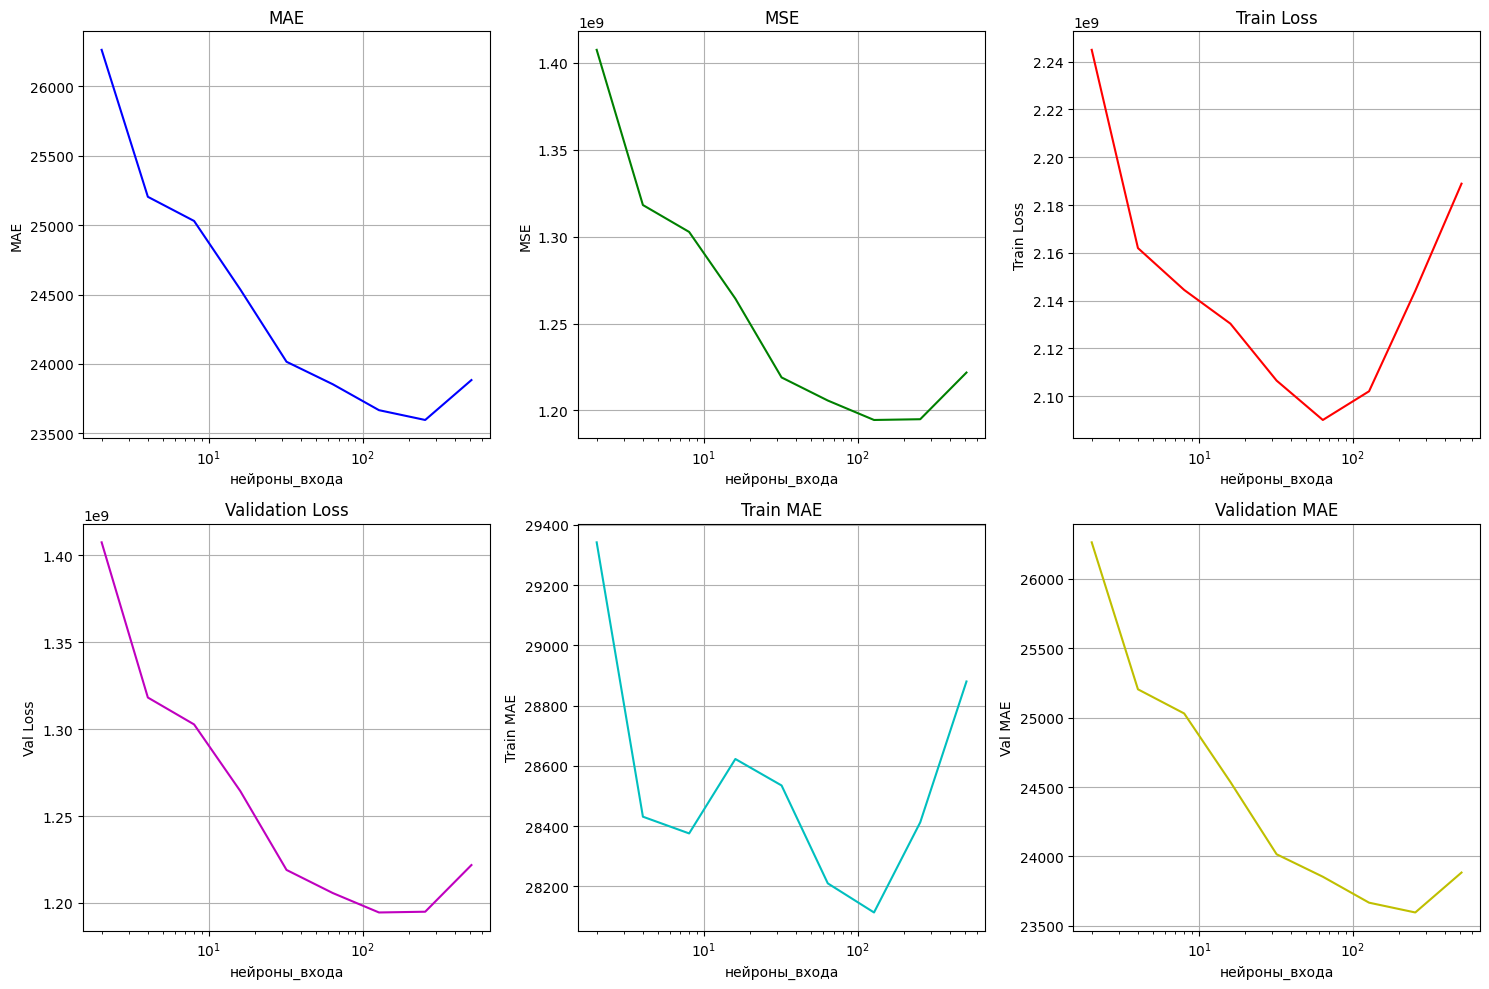

In [30]:
plots('нейроны_входа', df_results_vhod)


- [ ] Добавьте в нейронную сеть скрытый слой с разным количеством нейронов.



In [31]:
df_results_skrit = get_results(neurons_skrit=[2, 4, 8, 16, 32, 64, 128, 256, 512])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step  
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [32]:
df_results_skrit

,нейроны_входа,нейроны_скрытые,batch_size,эпохи,оптимизатор,функция_потерь,mae,mse,loss_train,loss_val,mae_train,mae_val
0,64,2,32,50,adam,mse,23656.886719,1.195082e+09,2.122651e+09,1.195082e+09,28268.841797,23656.886719
1,64,4,32,50,adam,mse,23641.968750,1.196196e+09,2.140822e+09,1.196196e+09,28408.125000,23641.972656
2,64,8,32,50,adam,mse,23730.380859,1.206942e+09,2.175113e+09,1.206942e+09,28728.773438,23730.382812
3,64,16,32,50,adam,mse,23857.509766,1.218608e+09,2.195544e+09,1.218608e+09,28947.146484,23857.511719
4,64,32,32,50,adam,mse,24153.363281,1.242769e+09,2.219693e+09,1.242769e+09,29258.271484,24153.359375
5,64,64,32,50,adam,mse,23544.605469,1.186879e+09,2.203762e+09,1.186879e+09,29130.035156,23544.605469
6,64,128,32,50,adam,mse,23596.093750,1.189176e+09,2.215068e+09,1.189176e+09,29044.158203,23596.089844
7,64,256,32,50,adam,mse,23867.253906,1.208624e+09,2.220804e+09,1.208624e+09,29072.294922,23867.250000
8,64,512,32,50,adam,mse,24159.708984,1.227590e+09,2.249633e+09,1.227590e+09,29231.685547,24159.710938


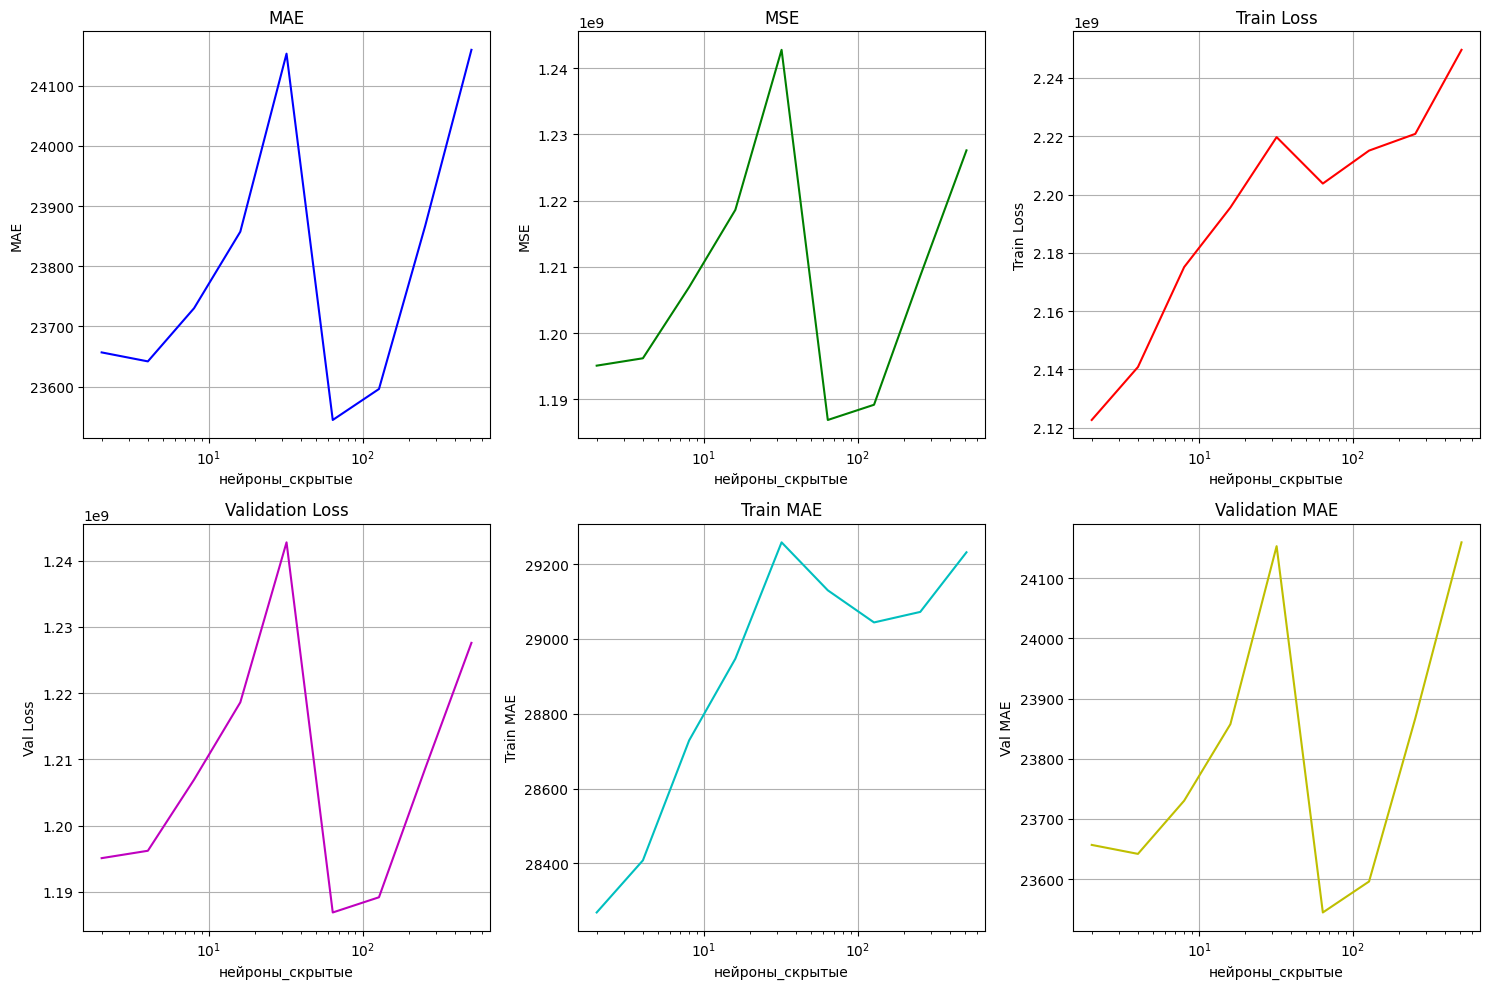

In [33]:
plots('нейроны_скрытые', df_results_skrit)

- [ ] Используйте разные размеры мини-выборки (batch_size). Опишите достигнутый результат.


In [34]:
df_results_batch = get_results(batch_size=[2, 8, 16, 32])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [35]:
df_results_batch

,нейроны_входа,нейроны_скрытые,batch_size,эпохи,оптимизатор,функция_потерь,mae,mse,loss_train,loss_val,mae_train,mae_val
0,64,0,2,50,adam,mse,24044.687500,1.213379e+09,2.327132e+09,1.213379e+09,29743.177734,24044.685547
1,64,0,8,50,adam,mse,23917.326172,1.216042e+09,2.290145e+09,1.216042e+09,29474.103516,23917.326172
2,64,0,16,50,adam,mse,23577.195312,1.191671e+09,2.171110e+09,1.191671e+09,28439.589844,23577.193359
3,64,0,32,50,adam,mse,23826.013672,1.203999e+09,2.088026e+09,1.203999e+09,28144.771484,23826.011719


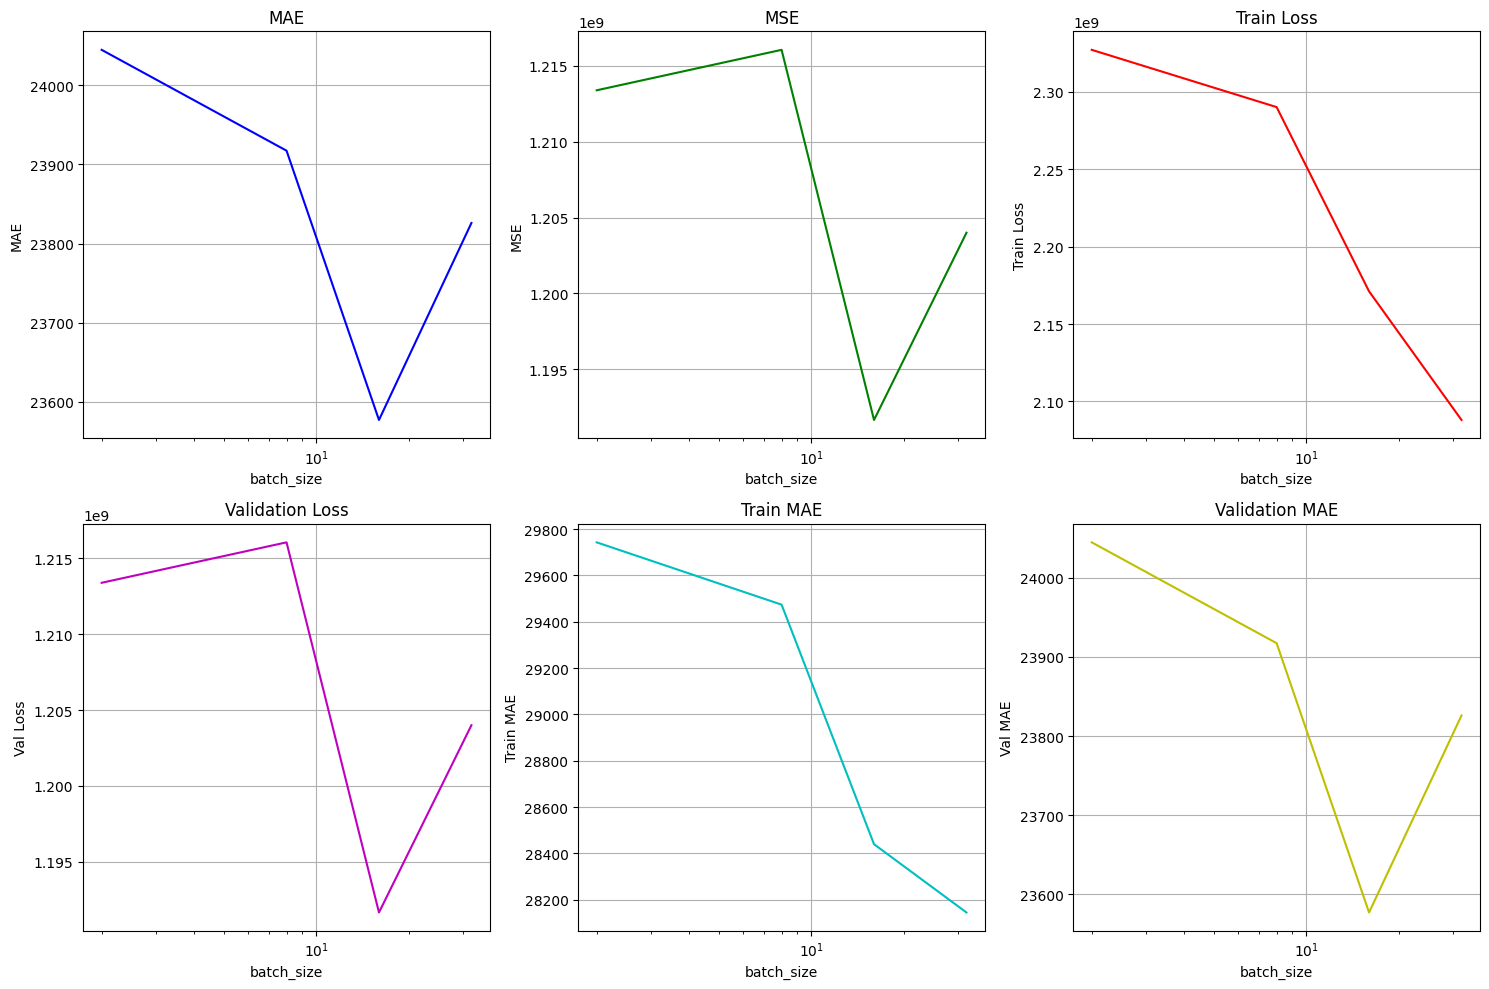

In [36]:
plots('batch_size', df_results_batch)

- [ ] Используйте разное количество эпох. Опишите достигнутый результат.



In [37]:
df_results_epoch = get_results(epoch_count=[10, 50, 100, 200])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [38]:
df_results_epoch

,нейроны_входа,нейроны_скрытые,batch_size,эпохи,оптимизатор,функция_потерь,mae,mse,loss_train,loss_val,mae_train,mae_val
0,64,0,32,10,adam,mse,25459.009766,1.366445e+09,2.315610e+09,1.366445e+09,30754.023438,25459.011719
1,64,0,32,50,adam,mse,23823.498047,1.203972e+09,2.088391e+09,1.203972e+09,28171.132812,23823.500000
2,64,0,32,100,adam,mse,23198.582031,1.158723e+09,2.006620e+09,1.158723e+09,27431.074219,23198.583984
3,64,0,32,200,adam,mse,21138.255859,1.005366e+09,1.830755e+09,1.005366e+09,25540.343750,21138.255859


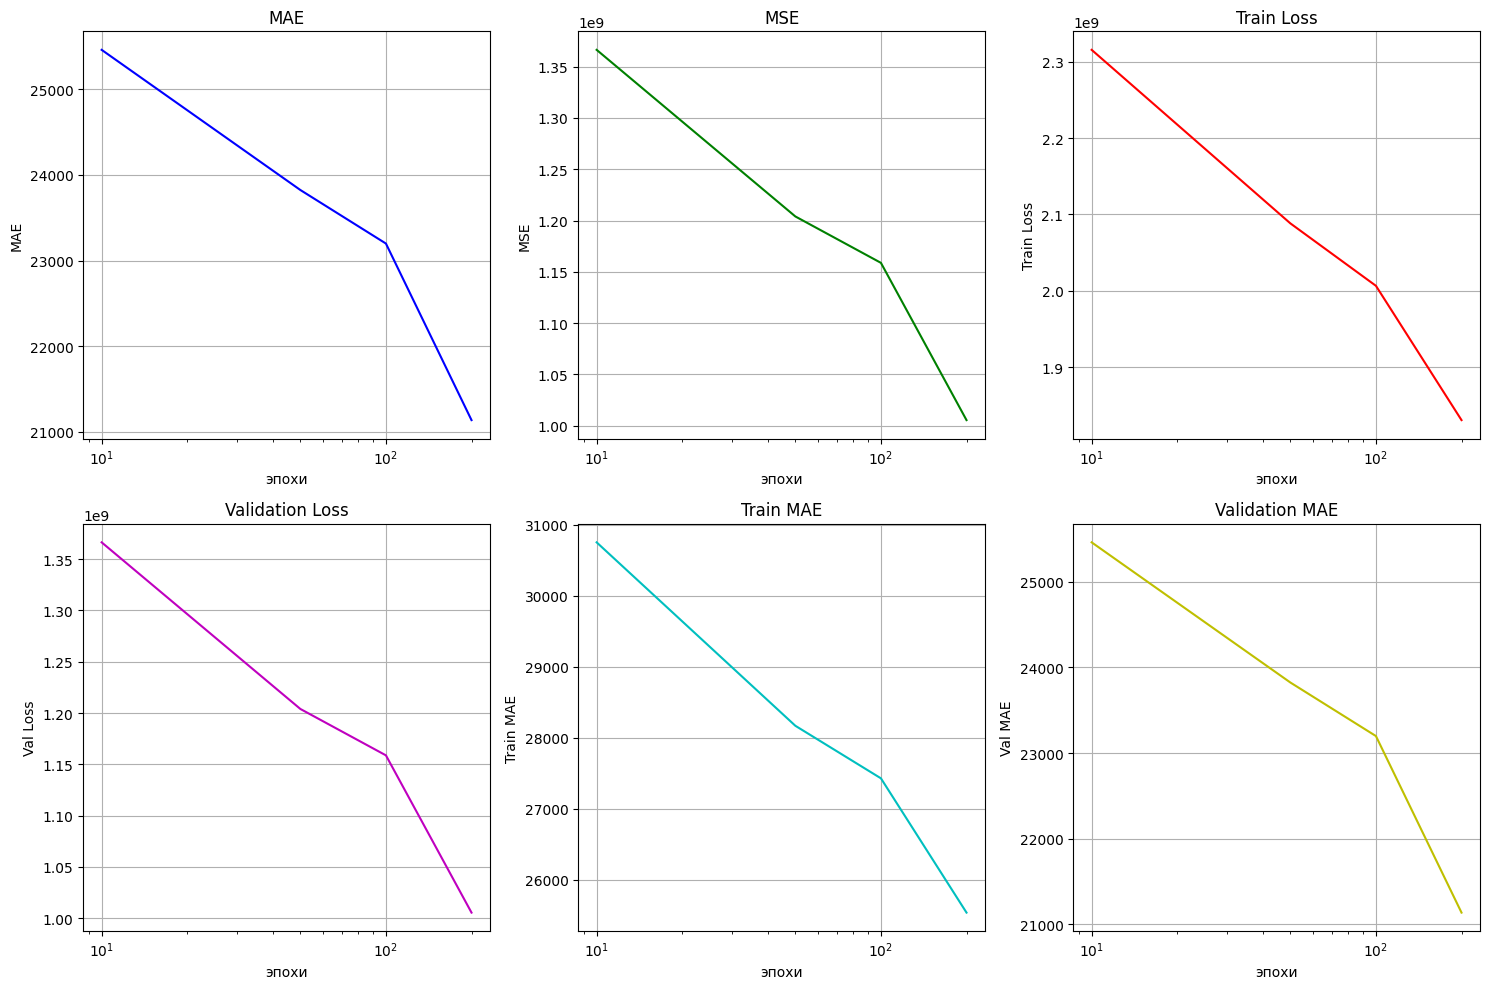

In [39]:
plots('эпохи', df_results_epoch)

- [ ] Попробуйте использовать разные значения оптимизатора `optimizers`. Сравните полученные результаты.



In [40]:
df_results_optim = get_results(optimizers=['rmsprop','adam', 'adamax', 'nadam'])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step  


In [41]:
df_results_optim

,нейроны_входа,нейроны_скрытые,batch_size,эпохи,оптимизатор,функция_потерь,mae,mse,loss_train,loss_val,mae_train,mae_val
0,64,0,32,50,rmsprop,mse,29556.859375,1.686323e+09,2.570745e+09,1.686323e+09,32957.343750,29556.859375
1,64,0,32,50,adam,mse,23849.841797,1.206004e+09,2.089778e+09,1.206004e+09,28191.830078,23849.841797
2,64,0,32,50,adamax,mse,34856.089844,2.265526e+09,3.085977e+09,2.265526e+09,37404.953125,34856.089844
3,64,0,32,50,nadam,mse,25262.500000,1.324728e+09,2.175532e+09,1.324728e+09,28600.222656,25262.498047


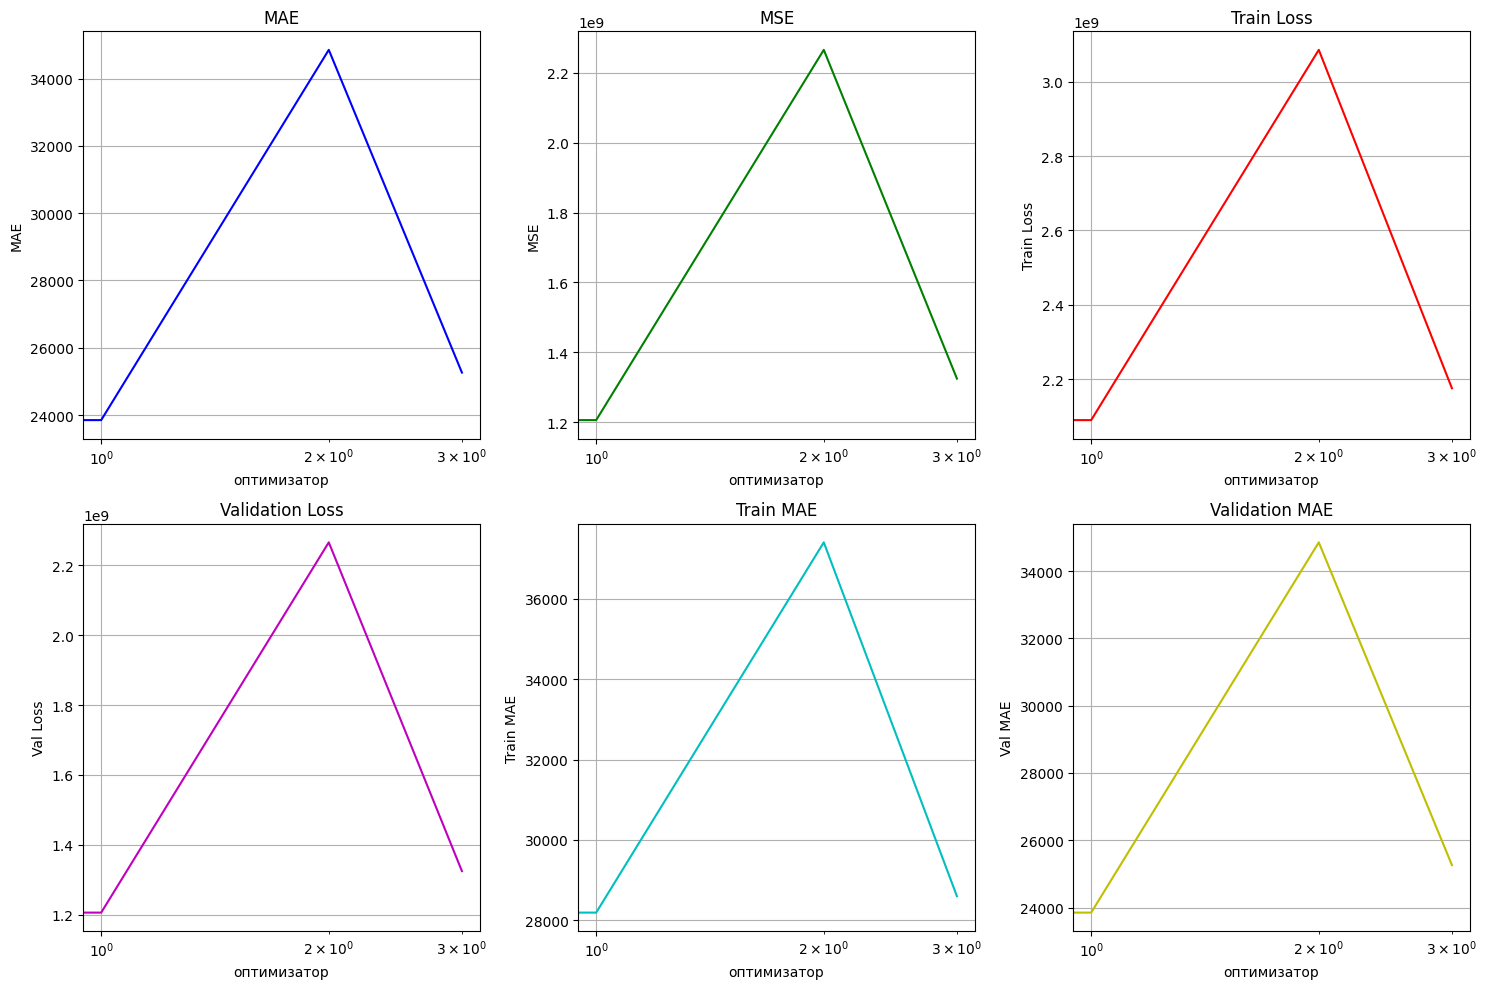

In [42]:
plots('оптимизатор', df_results_optim)

In [46]:
df_results_loss = get_results(losses=['mse', 'mae', 'huber'])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [47]:
df_results_loss

,нейроны_входа,нейроны_скрытые,batch_size,эпохи,оптимизатор,функция_потерь,mae,mse,loss_train,loss_val,mae_train,mae_val
0,64,0,32,50,adam,mse,23841.275391,1.205100e+09,2.089155e+09,1.205100e+09,28179.587891,23841.275391
1,64,0,32,50,adam,mae,23453.187500,1.175408e+09,2.682011e+04,2.345319e+04,26820.113281,23453.187500
2,64,0,32,50,adam,huber,23861.021484,1.206878e+09,2.692766e+04,2.386052e+04,26928.160156,23861.021484


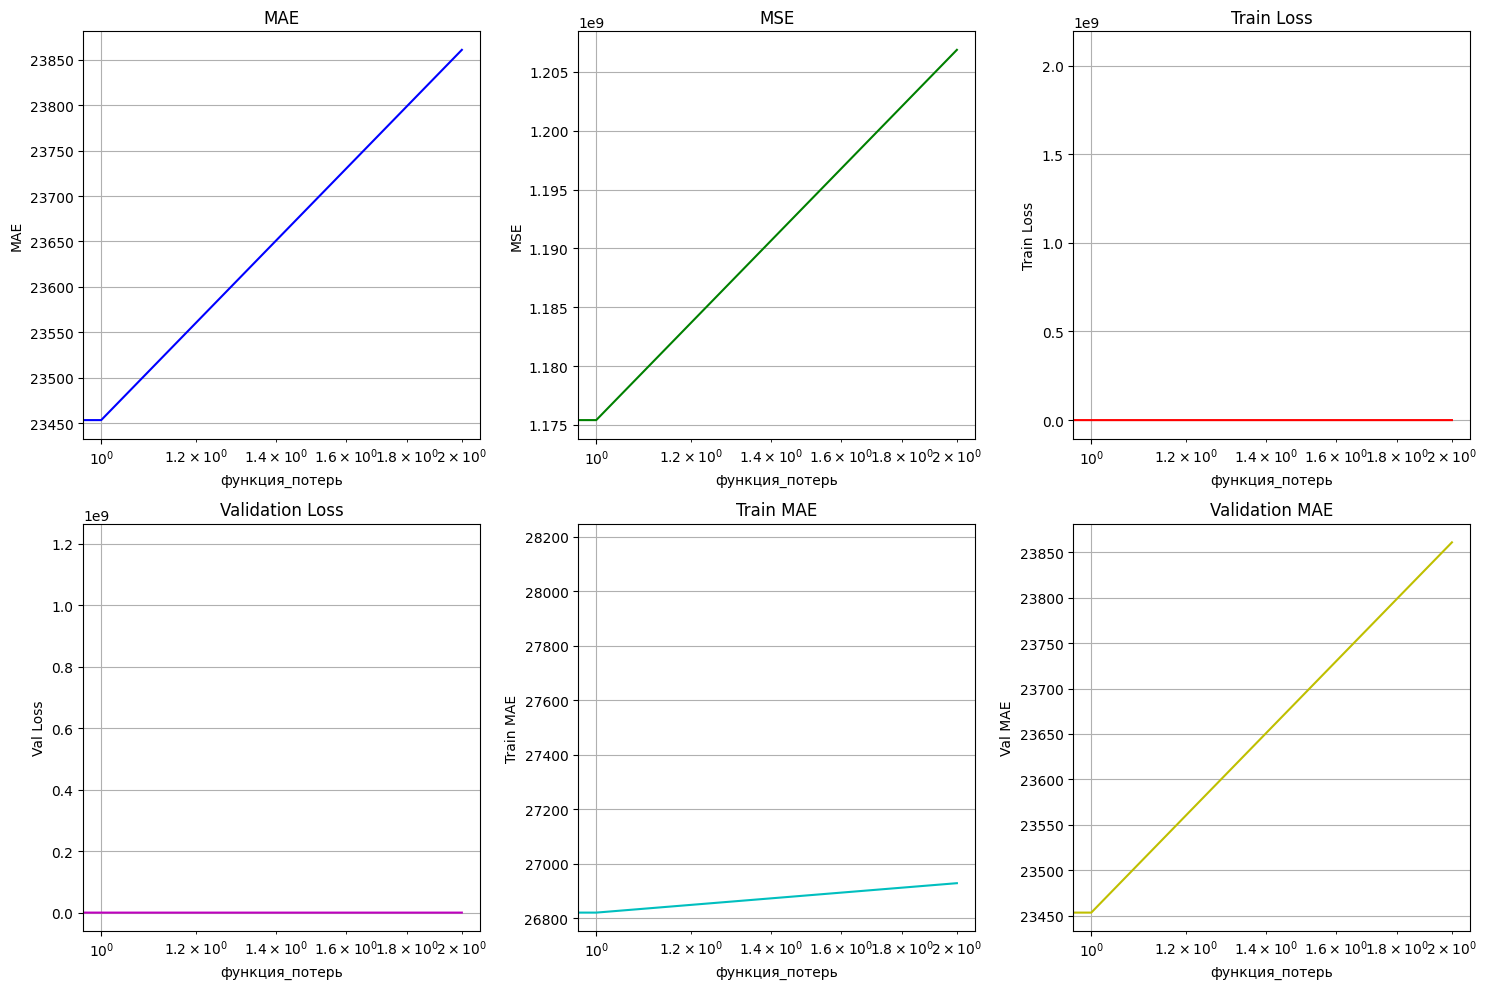

In [48]:
plots('функция_потерь', df_results_loss)

**Вопросы:**

Как выше перечисленные параметры влияют на полученный вами результат?

Что такое эпоха (Epoch)? В чем отличие от итерации (Iteration)?

Что такое функция активации? Какие вам известны? Как и зачем используются в нейронной сети?

Что такое MSE(Mean Squared Error) - Средняя квадратичная ошибка? Что такое MAE(Mean Absolute Error)? Для чего используются.